# Exercise 8: Instrument Recognition – Multitrack Datasets

## Imports

In [69]:
import pathlib
import random
from typing import Union

import librosa
import numpy as np
from matplotlib import pyplot as plt


## Constants

In [70]:
current_dir = pathlib.Path.cwd()

# Dataset
data_path = current_dir.joinpath("data")

# File extensions
TRACKS_FILE_EXTENSION = ".wav"
MIX_FILE_EXTENSION = ".mp3"

# File paths
track_file_paths = sorted(data_path.glob(f"*{TRACKS_FILE_EXTENSION}"))
print(track_file_paths)
mix_file_path = list(data_path.glob(f"*{MIX_FILE_EXTENSION}"))
assert len(mix_file_path) == 1, f"Mix file with extension {MIX_FILE_EXTENSION} not found!"
mix_file_path = mix_file_path[0]

[PosixPath('/Users/martijuanola/git_repositories/RWTH-AIiM/exercices/e8/data/01_Kick.wav'), PosixPath('/Users/martijuanola/git_repositories/RWTH-AIiM/exercices/e8/data/02_Snare.wav'), PosixPath('/Users/martijuanola/git_repositories/RWTH-AIiM/exercices/e8/data/03_Tom1.wav'), PosixPath('/Users/martijuanola/git_repositories/RWTH-AIiM/exercices/e8/data/04_Tom2.wav'), PosixPath('/Users/martijuanola/git_repositories/RWTH-AIiM/exercices/e8/data/05_Overheads.wav'), PosixPath('/Users/martijuanola/git_repositories/RWTH-AIiM/exercices/e8/data/06_Bass.wav'), PosixPath('/Users/martijuanola/git_repositories/RWTH-AIiM/exercices/e8/data/07_ElecGtr1.wav'), PosixPath('/Users/martijuanola/git_repositories/RWTH-AIiM/exercices/e8/data/08_ElecGtr2.wav'), PosixPath('/Users/martijuanola/git_repositories/RWTH-AIiM/exercices/e8/data/09_LeadVox.wav'), PosixPath('/Users/martijuanola/git_repositories/RWTH-AIiM/exercices/e8/data/10_BackingVox1.wav'), PosixPath('/Users/martijuanola/git_repositories/RWTH-AIiM/exercic

## Read and Process Data

In [71]:
class Track:
    track_name: str

    data: np.ndarray
    sr: Union[int, float]

    length: float

    def __init__(self, path: pathlib.Path):
        self.data, self.sr = librosa.load(path)
        self.track_name = self._get_track_name_from_path(path)

        self.length = len(self.data) / self.sr

    @staticmethod
    def _get_track_name_from_path(path: pathlib.Path) -> str:
        return str(path).split("/")[-1].split(".")[0]

    def __str__(self):
        return f"Track({self.track_name}, sr={self.sr}, length={self.length:.1f})"


tracks = []
for track_file_path in track_file_paths:
    tracks.append(Track(track_file_path))

mix = Track(mix_file_path)

In [72]:
print("Tracks:")
for track in tracks:
    print(track)
print("Mix:")
print(mix)

Tracks:
Track(01_Kick, sr=22050, length=205.0)
Track(02_Snare, sr=22050, length=205.0)
Track(03_Tom1, sr=22050, length=205.0)
Track(04_Tom2, sr=22050, length=205.0)
Track(05_Overheads, sr=22050, length=205.0)
Track(06_Bass, sr=22050, length=205.0)
Track(07_ElecGtr1, sr=22050, length=205.0)
Track(08_ElecGtr2, sr=22050, length=205.0)
Track(09_LeadVox, sr=22050, length=205.0)
Track(10_BackingVox1, sr=22050, length=205.0)
Track(11_BackingVox2, sr=22050, length=205.0)
Mix:
Track(Juanita Dientes Verdes_Placido Domingo_mix, sr=22050, length=204.9)


## E1: Visualisation

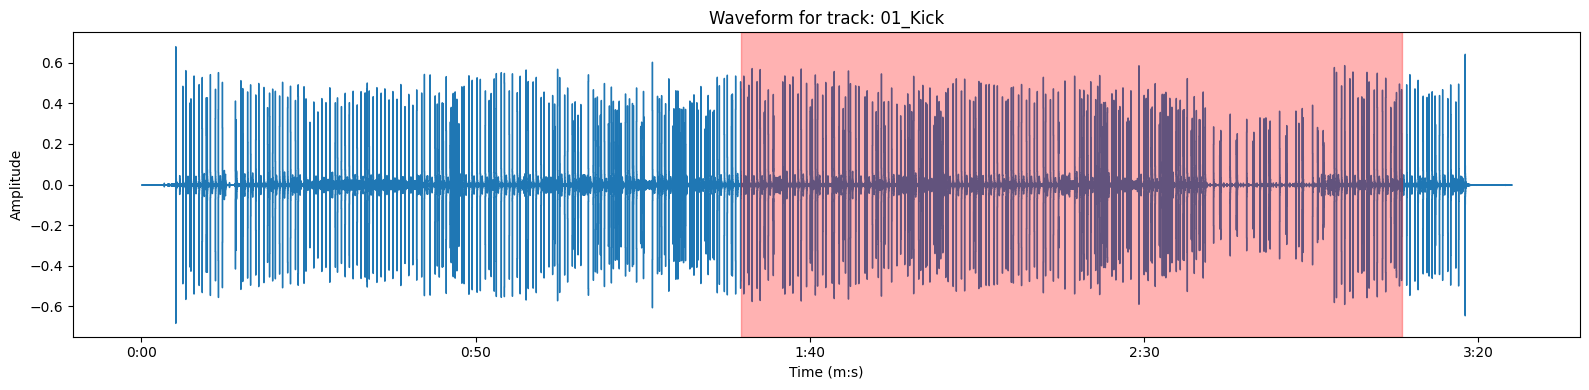

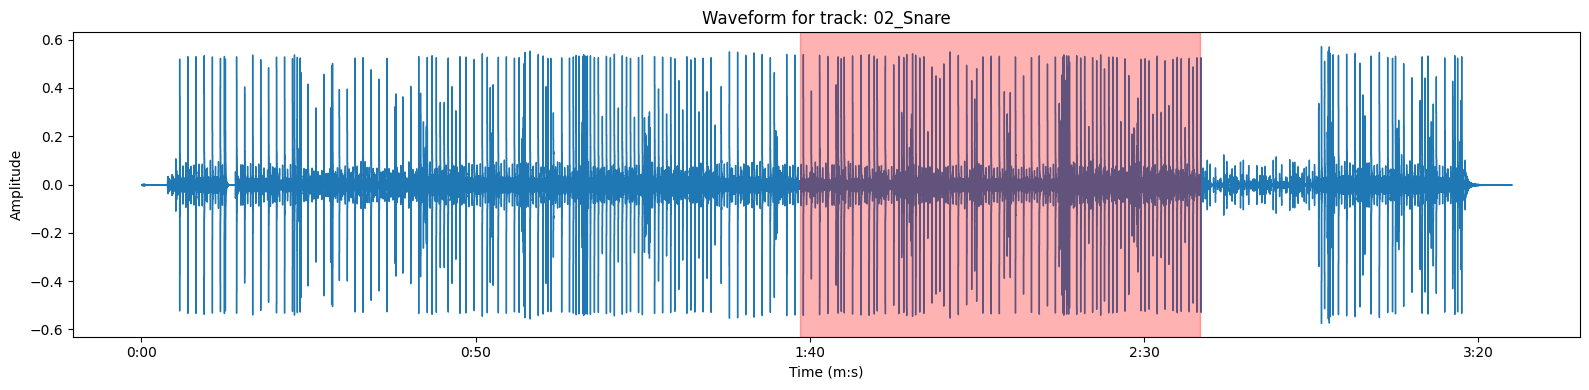

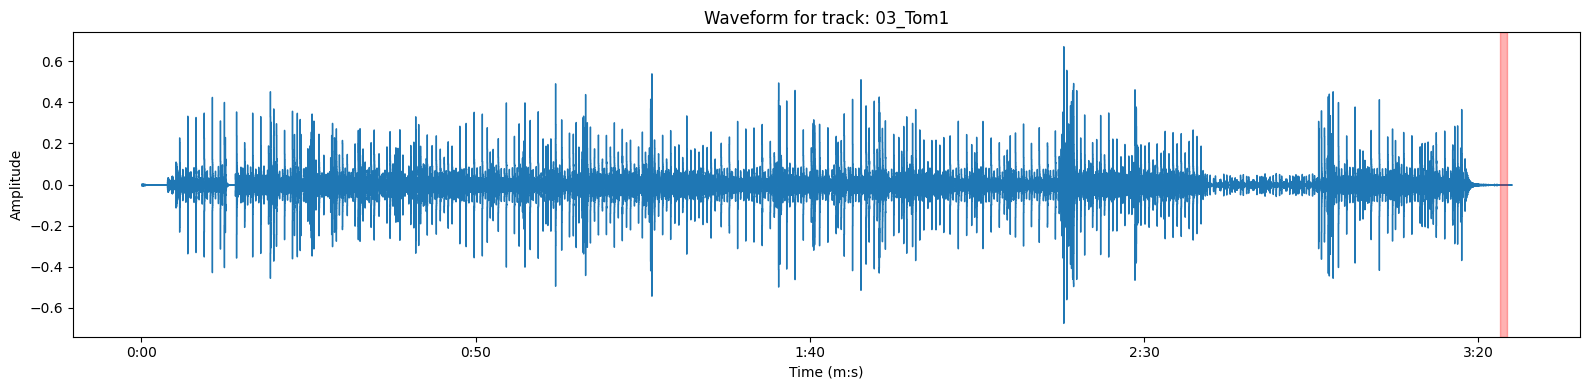

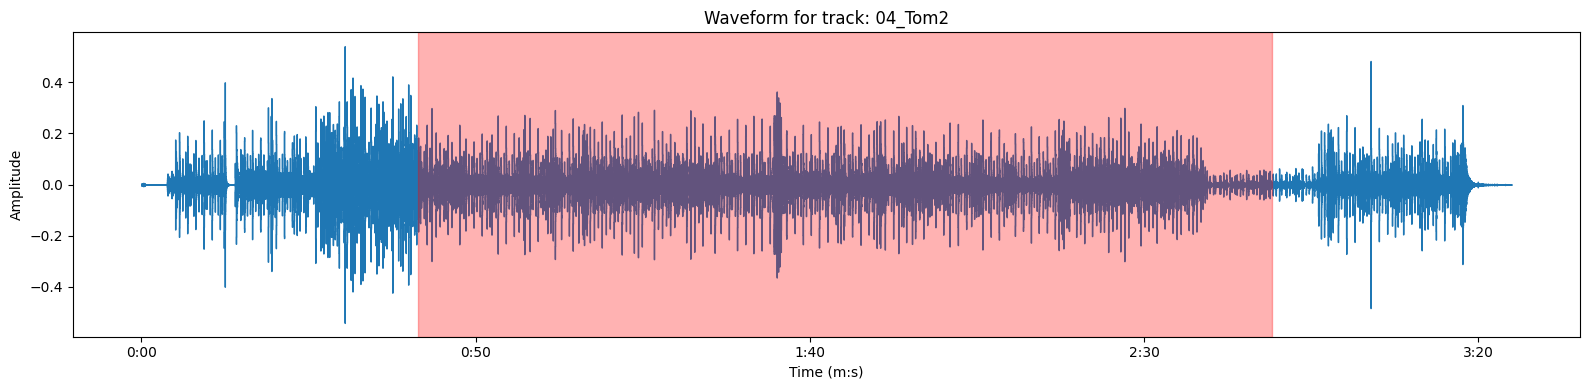

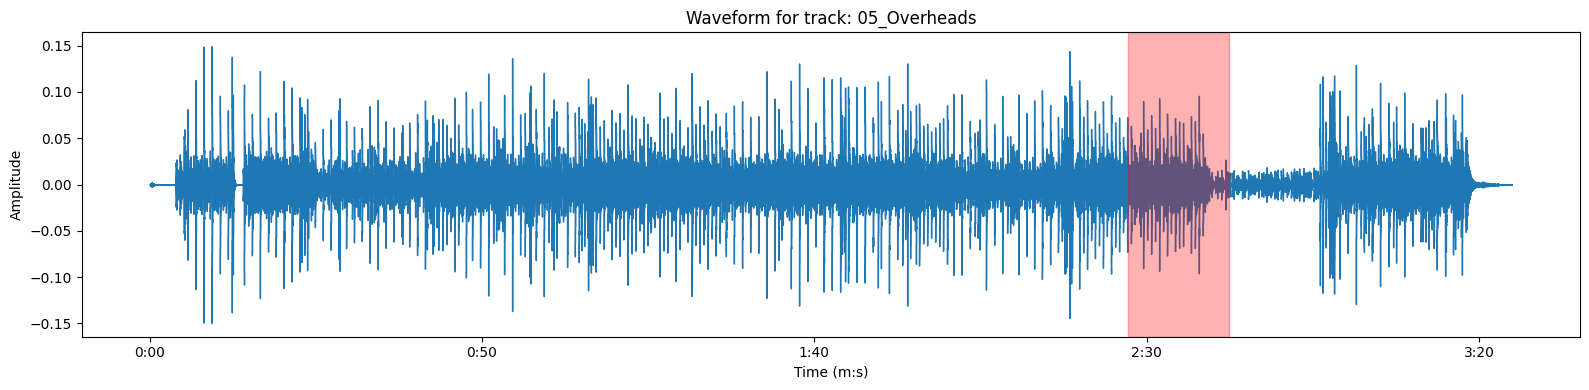

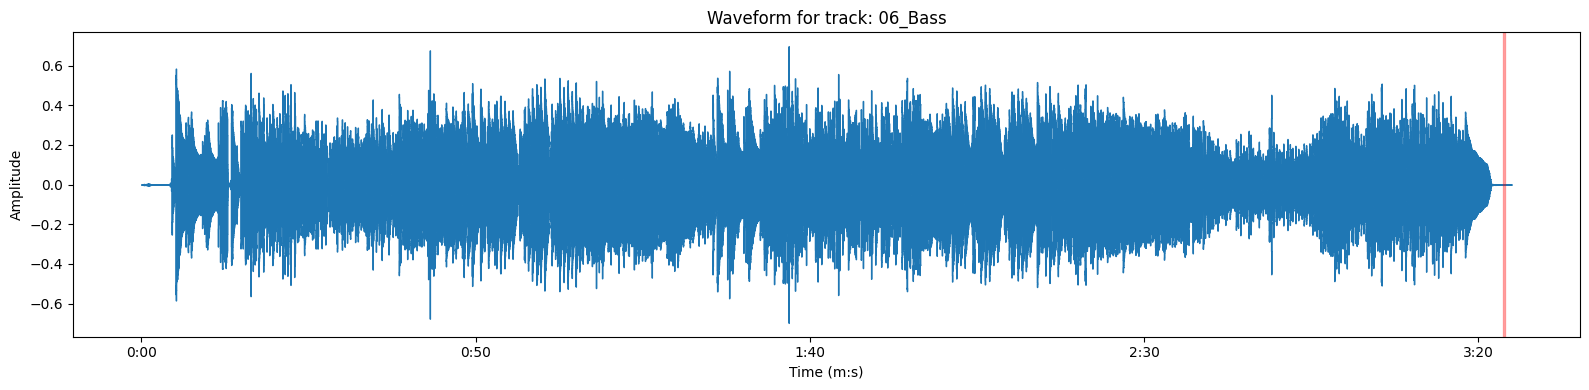

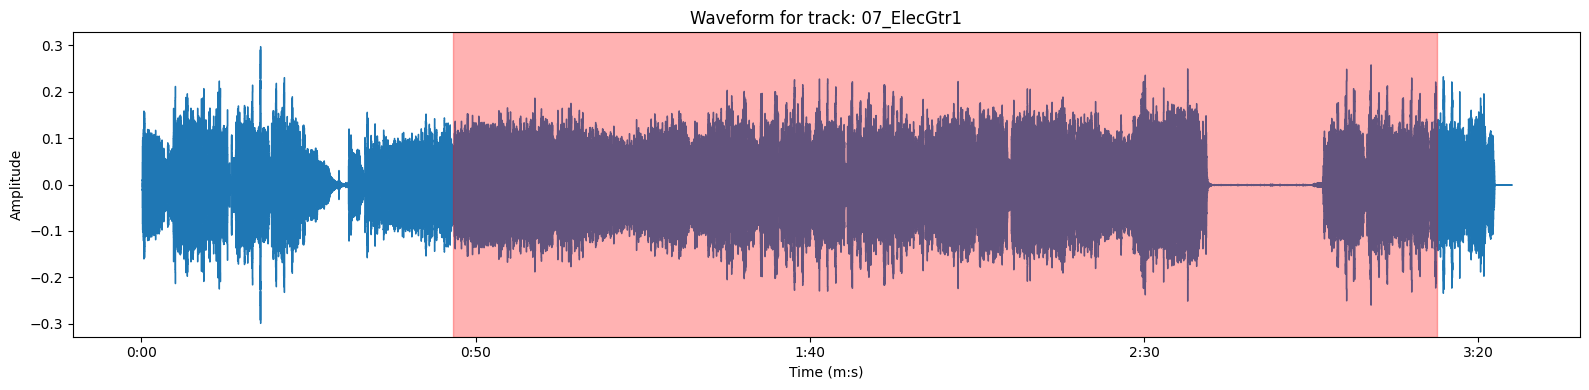

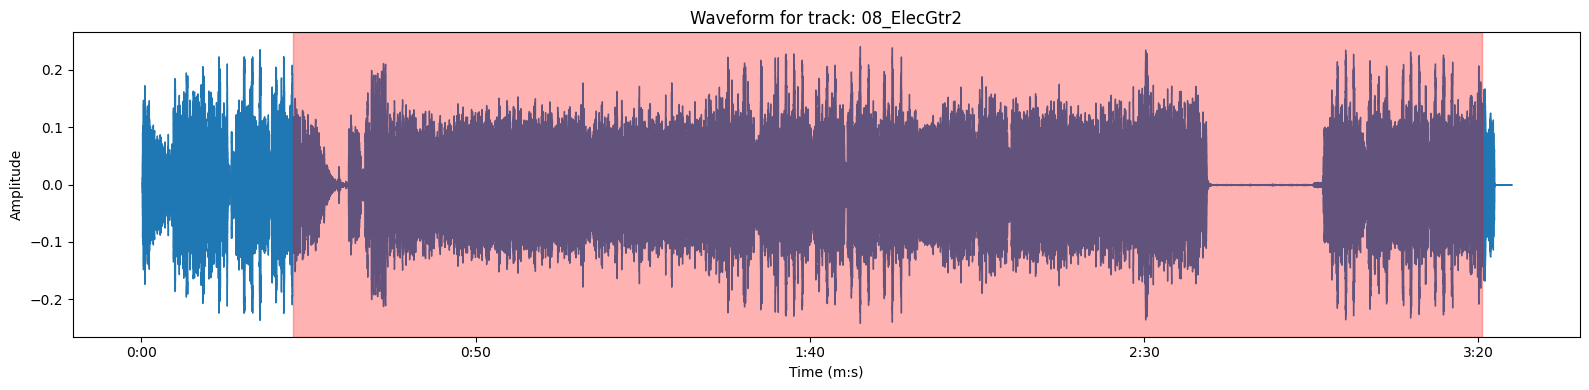

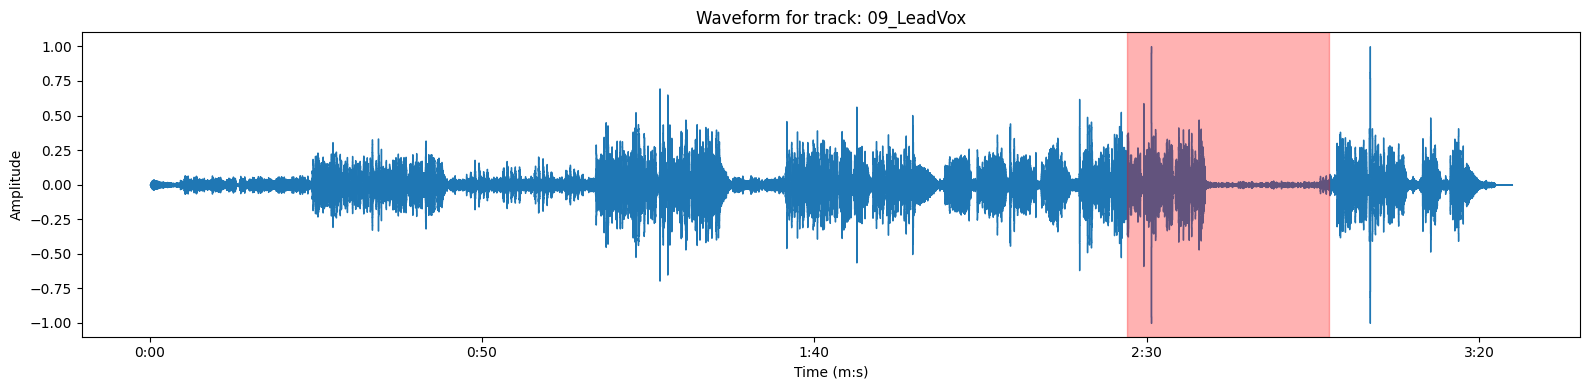

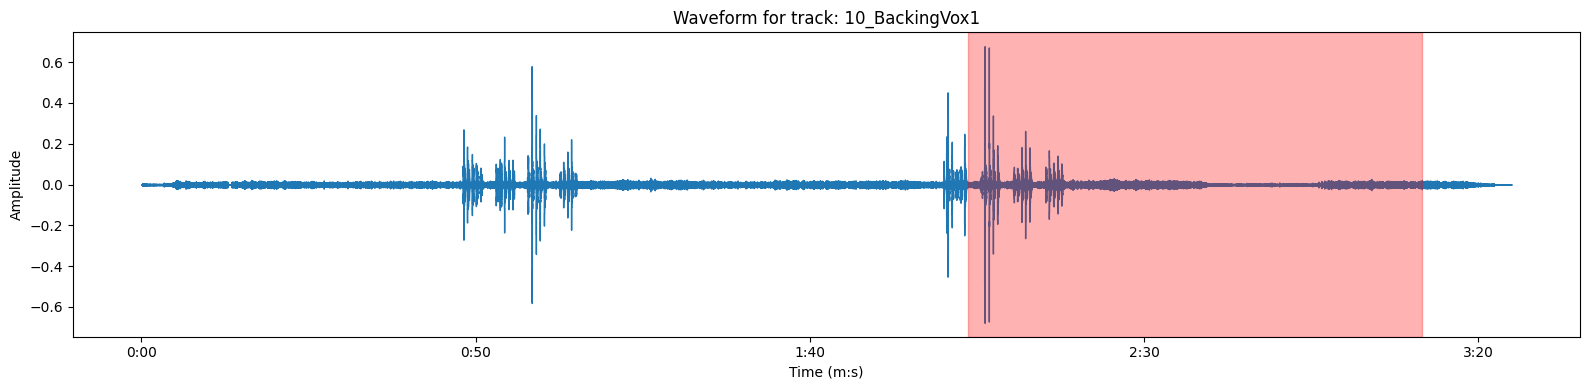

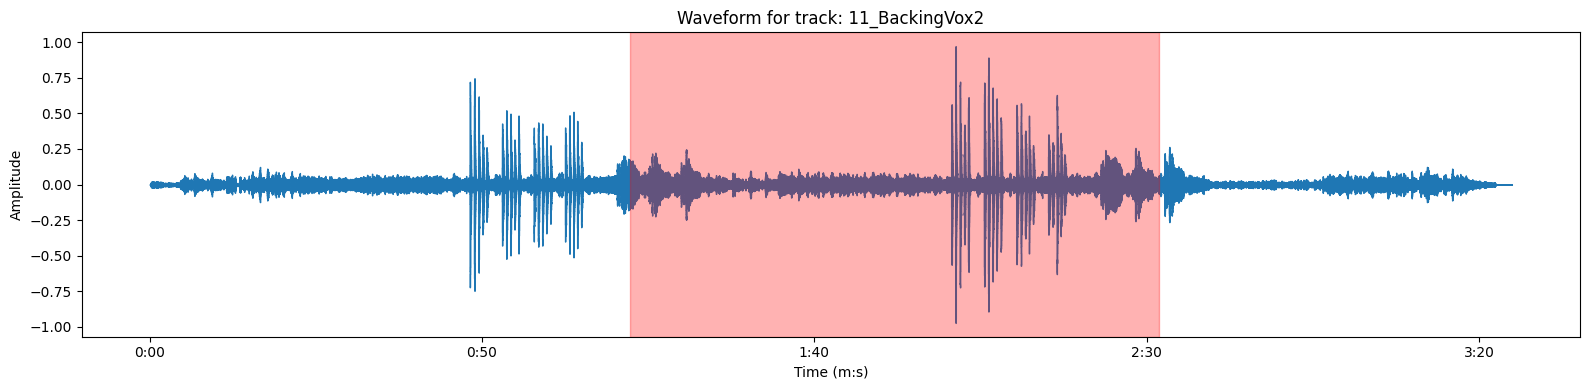

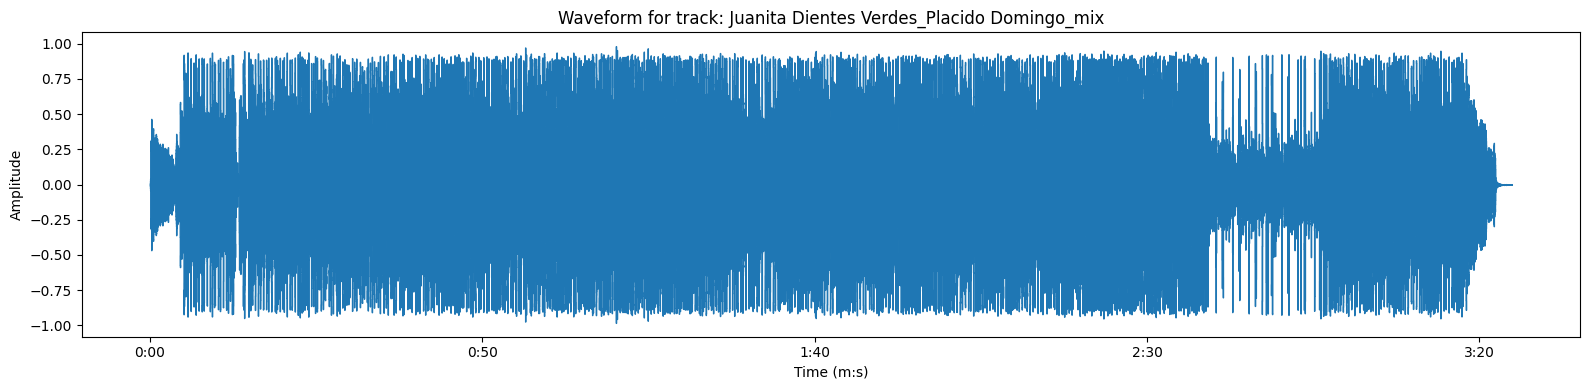

In [77]:



class TrackSection:
    start_time: float
    end_time: float

    def __init__(self, start_time: float, end_time: float):
        assert start_time > 0, "start_time is negative!"
        assert end_time > 0, "end_time is negative!"
        assert start_time < end_time, "start_time should be less than end_time!"

        self.start_time: float = start_time
        self.end_time: float = end_time


def get_random_track_section(track_length: float) -> TrackSection:
    start_time: float = random.uniform(0, track_length)
    while start_time == track_length:
        start_time = random.uniform(0, track_length)
    end_time: float = start_time
    while start_time == end_time:
        end_time = random.uniform(start_time, track_length)
    return TrackSection(start_time, end_time)


def plot_highlighted_waveform(track: Track, sections_to_highlight: list[TrackSection] = None,
                              figure_size: tuple[int, int] = (16, 4), title: str = None, highlight_color: str = "red",
                              highlight_alpha: float = 0.3):
    if title is None:
        title = f"Waveform for track: {track.track_name}"
    if sections_to_highlight is None:
        sections_to_highlight = []

    # Print waveform
    plt.figure(figsize=figure_size)
    librosa.display.waveshow(track.data, sr=track.sr)
    plt.title(title)
    plt.xlabel("Time (m:s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()

    # Add sections
    ax = plt.gca()
    for section in sections_to_highlight:
        ax.axvspan(section.start_time, section.end_time, color=highlight_color, alpha=highlight_alpha)

    plt.show()


for track in tracks:
    plot_highlighted_waveform(track, [get_random_track_section(track.length)])

plot_highlighted_waveform(mix)

## E2: Instrument Activity Detection

In [35]:
# TODO: !!

## E3: Audio Bleed

In [36]:
# TODO: !!